# Section 4: Consumer Welfare — Compensating Variation
**Member 2** — Work on this section, then integrate into the main notebook.

**Your responsibility:** Quasi-linear utility function, household energy demand calibration, compensating variation (two methods: utility difference + numerical integration), welfare loss visualization. You should be able to explain: quasi-linear utility, why CV = area under demand curve, the role of demand elasticity, and the gas-to-electricity passthrough.

---

*The setup cells below (imports + solvers) are shared across all members.*

# Who Gains When Gas Prices Surge?
## A Welfare Analysis of Norway's Gas Economy Under the Ukraine War Supply Shock

**EBA3650 — Quantitative Economics**
BI Norwegian Business School | Spring 2026 | Group of 4

### Research Question

The 2022 Russian invasion of Ukraine triggered one of the largest energy supply shocks in recent history. As Russian pipeline gas to Europe was curtailed — from roughly 155 bcm/year to under 30 bcm — European gas prices surged to unprecedented levels, with TTF spot prices exceeding EUR 300/MWh in August 2022.

Norway — as Europe's now-largest pipeline gas supplier — found itself at the centre of this shift.

This project asks: **Does Norway benefit from the war-induced gas price surge, and if so, who within Norway captures the gains?**

We decompose the welfare effects across three agents:
1. **Gas-producing firms** — producer surplus gain
2. **Norwegian consumers** — welfare loss from higher energy prices
3. **The Norwegian state** — government revenue gain via the 78% petroleum tax

We aggregate these into a net welfare measure and test robustness through sensitivity analysis across key structural parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

### Custom Numerical Solvers

We implement the secant method and Newton's method from Sessions 2–3 as our primary equation solvers, then verify results with `scipy.optimize`.

In [2]:
# Secant method for equation solving (Session 3)
def our_secant_solver(funcname, x1, x2, arglist):
    y1 = funcname(x1, arglist)
    for _ in range(200):
        y2 = funcname(x2, arglist)
        if abs(y1) < 1e-10:
            return x1
        x_new = x1 - y1 * (x2 - x1) / (y2 - y1)
        x1 = x2
        y1 = y2
        x2 = x_new
    return x2

# Newton's method with numerical derivatives (Session 3)
def our_newton_solver(funcname, startvalue, arglist):
    current = startvalue
    fval = funcname(current, arglist)
    grad = (funcname(current + 0.5e-5, arglist) - funcname(current - 0.5e-5, arglist)) * 1e5
    while abs(fval) > 1e-10:
        current = current - fval / grad
        fval = funcname(current, arglist)
        grad = (funcname(current + 0.5e-5, arglist) - funcname(current - 0.5e-5, arglist)) * 1e5
    return current

# Quick test on a known equation: x^2 - 4 = 0 => x = 2
def test_eq(x, args):
    return x**2 - 4

print(f"Secant solver:  x = {our_secant_solver(test_eq, 1, 3, None):.8f}")
print(f"Newton solver:  x = {our_newton_solver(test_eq, 3, None):.8f}")
print("Both solvers verified: x^2 = 4 => x = 2.0")

Secant solver:  x = 2.00000000
Newton solver:  x = 2.00000000
Both solvers verified: x^2 = 4 => x = 2.0


In [3]:
# === Values from Section 3 (Member 1's work) ===
# These will come from the full notebook. For now, hardcoded so you can work independently.

P0 = 20.0            # pre-war gas price (EUR/MWh)
Q0 = 4000.0          # pre-war quantity (TWh/yr)
eps_d = -0.3
eps_s = 0.35
A_d = Q0 / P0**eps_d
A_s = Q0 / P0**eps_s
delta = 0.40
norway_share = 0.25
A_NO = norway_share * A_s

def demand(price, level, el):
    return level * price**el

def supply(price, level, el):
    return level * price**el

def inverse_supply(q, level, el):
    return (q / level)**(1.0 / el)

def ps_analytical(eq_price, A, eps):
    Q = supply(eq_price, A, eps)
    cost_integral = A**(-1/eps) * Q**(1 + 1/eps) / (1 + 1/eps)
    return eq_price * Q - cost_integral

# Solve for post-shock price
P1_scipy = opt.bisect(lambda p: demand(p, A_d, eps_d) - supply(p, (1-delta)*A_s, eps_s), 1, 500)
Q1_scipy = demand(P1_scipy, A_d, eps_d)
PS_pre_analytical = ps_analytical(P0, A_NO, eps_s)
PS_post_analytical = ps_analytical(P1_scipy, A_NO, eps_s)
delta_PS = PS_post_analytical - PS_pre_analytical
scale = 1e3

print(f'Post-shock price: {P1_scipy:.2f} EUR/MWh')
print(f'Delta PS: {delta_PS/scale:.2f} bn EUR')


Post-shock price: 43.89 EUR/MWh
Delta PS: 27.99 bn EUR


## 4. Consumer Welfare: Compensating Variation

Norwegian households face higher energy prices as European gas prices feed through to Nordic electricity markets via interconnectors (NordLink to Germany, North Sea Link to UK). We measure the welfare loss using **compensating variation** (CV) from consumer theory (Sessions 3–4).

### Quasi-linear utility

We use a quasi-linear utility function:

$$u(g, y) = y + \frac{B}{1 - 1/\eta} \cdot g^{1 - 1/\eta}$$

where $g$ is energy consumption, $y$ is all other goods (numeraire), $B$ is a preference parameter, and $\eta$ is the price elasticity of energy demand.

The first-order condition gives demand: $g(p) = (B/p)^\eta$

**Key property of quasi-linear utility:** The compensating variation equals the change in consumer surplus — the area under the demand curve between the old and new prices:

$$CV = \int_{p_0}^{p_1} g(p) \, dp = V(p_0, I) - V(p_1, I)$$

In [4]:
# Quasi-linear utility functions (Session 5 pattern)
def utility_ql(g, y, B, eta):
    return y + B / (1 - 1/eta) * g**(1 - 1/eta)

def demand_energy(price, B, eta):
    return (B / price)**eta

def indirect_utility_ql(income, price, B, eta):
    g = demand_energy(price, B, eta)
    y = income - price * g
    return utility_ql(g, y, B, eta)

In [5]:
# Calibrate consumer parameters
eta_c = 0.3              # household energy demand elasticity (very inelastic short-run)
I_household = 50000.0    # representative household income (EUR/year)
n_households = 2.4e6     # ~2.4 million Norwegian households

# Gas-to-electricity price passthrough coefficient
# Norwegian electricity prices are influenced by European gas prices through
# market coupling, but Norway also has significant hydropower, dampening the effect
passthrough = 0.5

# Domestic energy prices
p_energy_pre = P0 * passthrough
p_energy_post = P1_scipy * passthrough

# Calibrate B so that pre-war energy expenditure is ~2000 EUR/yr per household
energy_spend_target = 2000.0  # EUR/year
g_target = energy_spend_target / p_energy_pre
# From demand: g = (B/p)^eta => B = p * g^(1/eta)
B_consumer = p_energy_pre * g_target**(1.0 / eta_c)

# Verify calibration
g_check = demand_energy(p_energy_pre, B_consumer, eta_c)
spend_check = p_energy_pre * g_check

print(f"=== Consumer Calibration ===")
print(f"Pre-war energy price:  {p_energy_pre:.1f} EUR/MWh")
print(f"Post-shock energy price: {p_energy_post:.1f} EUR/MWh  (+{(p_energy_post/p_energy_pre-1)*100:.0f}%)")
print(f"Pre-war energy demand: {g_check:.1f} MWh/yr per household")
print(f"Pre-war energy spend:  {spend_check:.0f} EUR/yr (target: {energy_spend_target:.0f})")
print(f"B_consumer = {B_consumer:.4f}")

# Check that numeraire consumption stays positive (quasi-linear validity)
g_post = demand_energy(p_energy_post, B_consumer, eta_c)
y_post = I_household - p_energy_post * g_post
print(f"Post-shock energy spend: {p_energy_post * g_post:.0f} EUR/yr")
print(f"Post-shock numeraire:    {y_post:.0f} EUR/yr (must be > 0: {'OK' if y_post > 0 else 'WARNING'})")

=== Consumer Calibration ===
Pre-war energy price:  10.0 EUR/MWh
Post-shock energy price: 21.9 EUR/MWh  (+119%)
Pre-war energy demand: 200.0 MWh/yr per household
Pre-war energy spend:  2000 EUR/yr (target: 2000)
B_consumer = 467842838.1141
Post-shock energy spend: 3467 EUR/yr
Post-shock numeraire:    46533 EUR/yr (must be > 0: OK)


In [6]:
# Compensating Variation: two methods

# Method 1: Utility difference (exact for quasi-linear)
V_pre = indirect_utility_ql(I_household, p_energy_pre, B_consumer, eta_c)
V_post = indirect_utility_ql(I_household, p_energy_post, B_consumer, eta_c)
CV_household = V_pre - V_post  # positive = welfare loss

# Method 2: Numerical integration of demand curve ("integration by force", Session 7)
p_grid = np.linspace(p_energy_pre, p_energy_post, 50000)
g_grid = demand_energy(p_grid, B_consumer, eta_c)
CV_integral = (p_energy_post - p_energy_pre) * np.mean(g_grid)

# Scale to all Norwegian households (convert to billion EUR)
CV_total = CV_household * n_households

print(f"=== Compensating Variation ===")
print(f"CV per household (utility method):    {CV_household:.2f} EUR/yr")
print(f"CV per household (integral method):   {CV_integral:.2f} EUR/yr")
print(f"Methods agree to: {abs(CV_household - CV_integral):.4f} EUR")
print(f"")
print(f"Total consumer welfare loss (Norway): {CV_total/1e9:.3f} bn EUR/yr")
print(f"  = {CV_total/n_households:.0f} EUR per household")

=== Compensating Variation ===
CV per household (utility method):    2095.60 EUR/yr
CV per household (integral method):   2095.60 EUR/yr
Methods agree to: 0.0008 EUR

Total consumer welfare loss (Norway): 5.029 bn EUR/yr
  = 2096 EUR per household


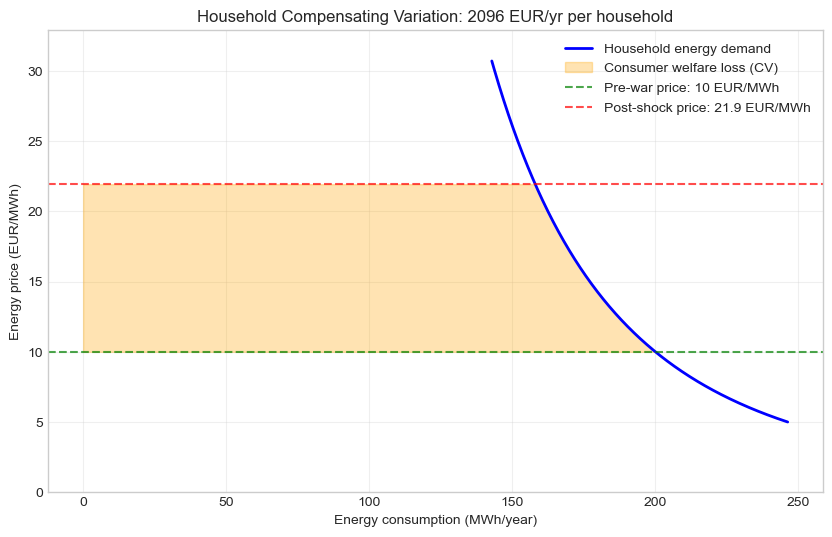

In [7]:
# Plot: Consumer welfare loss visualisation
p_wide = np.linspace(p_energy_pre * 0.5, p_energy_post * 1.4, 500)
g_wide = demand_energy(p_wide, B_consumer, eta_c)

p_fill = np.linspace(p_energy_pre, p_energy_post, 500)
g_fill = demand_energy(p_fill, B_consumer, eta_c)

plt.figure(figsize=(10, 6))
plt.plot(g_wide, p_wide, '-b', linewidth=2, label='Household energy demand')
plt.fill_betweenx(p_fill, demand_energy(p_fill, B_consumer, eta_c), 0,
                  alpha=0.3, color='orange', label=f'Consumer welfare loss (CV)')
plt.axhline(y=p_energy_pre, linestyle='--', color='green', alpha=0.7, label=f'Pre-war price: {p_energy_pre:.0f} EUR/MWh')
plt.axhline(y=p_energy_post, linestyle='--', color='red', alpha=0.7, label=f'Post-shock price: {p_energy_post:.1f} EUR/MWh')
plt.xlabel('Energy consumption (MWh/year)')
plt.ylabel('Energy price (EUR/MWh)')
plt.title(f'Household Compensating Variation: {CV_household:.0f} EUR/yr per household')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(0, p_energy_post * 1.5)
plt.show()

**Interpretation:** The compensating variation shows the monetary welfare loss per household from the energy price increase. Aggregated over 2.4 million Norwegian households, this gives the total consumer welfare loss — significant, but as we will see, much smaller than the producer surplus gain channelled through the government.

Note that the demand elasticity is very low ($\eta = 0.3$): households cannot easily reduce energy consumption in the short run, so they absorb most of the price increase through higher spending.